In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [2]:
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")

In [3]:
#preprocess data
def encode_gender(x):
    if x == 'Female':
        return 1
    elif x == 'Male':
        return 0
    else:
        return -1
    
def encode_customer_type(x):
    if x == 'Loyal Customer':
        return 1
    elif x == 'disloyal Customer':
        return 0
    else:
        return -1
    
def encode_type_of_travel(x):
    if x == 'Business travel':
        return 1
    elif x == 'Personal Travel':
        return 0
    else:
        return -1
    
def encode_class(x):
    if x == 'Business':
        return 2
    elif x == 'Eco Plus':
        return 1
    elif x == 'Economy':
        return 0
    else:
        return -1
    
def encode_satisfaction(x):
    if x == 'satisfied':
        return 1
    elif x == 'neutral or dissatisfied':
        return 0
    else:
        return -1 
    


In [4]:
def preprocess_data(df):
    #drop meaningless columns
    df = df.drop(columns=['id', 'Unnamed: 0'])

    #encode
    df['Gender'] = df['Gender'].apply(encode_gender)
    df['Customer Type'] = df['Customer Type'].apply(encode_customer_type)
    df['Type of Travel'] = df['Type of Travel'].apply(encode_type_of_travel)
    df['Class'] = df['Class'].apply(encode_class)
    df['satisfaction'] = df['satisfaction'].apply(encode_satisfaction)

    #feature engineering
    df['Age Group'] = pd.cut(df['Age'], bins=[0, 18, 30, 50, 100], labels=[0, 1, 2, 3])
    df['Flight Distance Group'] = pd.cut(df['Flight Distance'], bins=[0, 500, 1500, 3000, 5000], labels=[0, 1, 2, 3])
    df['Total Delay']  = df[['Departure Delay in Minutes', 'Arrival Delay in Minutes']].sum(axis=1)
    df['Service Score Average'] = (df['On-board service'] + df['Checkin service'] + df['Inflight service'] + df['Inflight wifi service']) / 4

    #drop original columns after feature engineering and original encoded columns
    df = df.drop(columns = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'On-board service', 'Checkin service', 'Inflight service', 'Inflight wifi service', 'Customer Type', 'Type of Travel'], errors='ignore')

    #drop the columns that are not used for modeling
    df = df.drop(columns = ['Departure/Arrival time convenient', 'Gate location'], errors='ignore')
    return df

train_processed = preprocess_data(train)
test_processed = preprocess_data(test)

In [5]:
#split data
X_train = train_processed.drop(columns=['satisfaction'], errors='ignore')
y_train = train_processed['satisfaction']
X_test = test_processed.drop(columns=['satisfaction'], errors='ignore')
y_test = test_processed['satisfaction']

In [6]:
#standardize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

ROC_AUC = 0.8250760839782086
              precision    recall  f1-score   support

           0    0.83397   0.87202   0.85257     14573
           1    0.82632   0.77813   0.80150     11403

    accuracy                        0.83081     25976
   macro avg    0.83014   0.82508   0.82704     25976
weighted avg    0.83061   0.83081   0.83015     25976



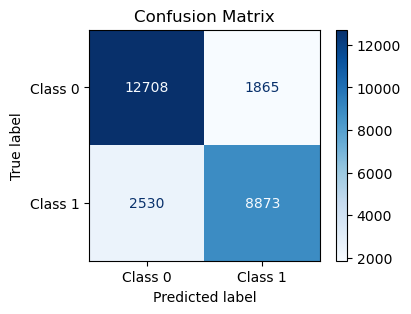

In [7]:
def run_model(model, X_train, y_train, X_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    roc_auc = roc_auc_score(y_test, y_pred)
    print("ROC_AUC = {}".format(roc_auc))
    print(classification_report(y_test,y_pred,digits=5))
    #confusion matrix
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['Class 0', 'Class 1'], cmap='Blues', ax=ax)
    plt.title('Confusion Matrix')
    plt.show()
    return model, y_pred

logistic_model, logistic_predictions = run_model(LogisticRegression(), X_train, y_train, X_test)

--- Dummy Baseline ---
ROC_AUC = 0.5
              precision    recall  f1-score   support

           0    0.56102   1.00000   0.71878     14573
           1    0.00000   0.00000   0.00000     11403

    accuracy                        0.56102     25976
   macro avg    0.28051   0.50000   0.35939     25976
weighted avg    0.31474   0.56102   0.40325     25976



/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

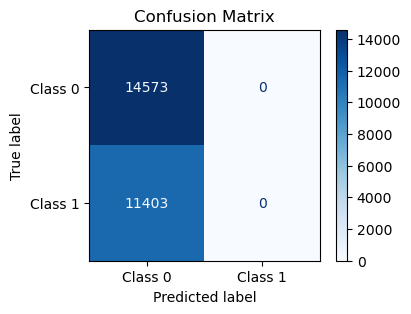


--- Logistic Regression Baseline ---
ROC_AUC = 0.8250760839782086
              precision    recall  f1-score   support

           0    0.83397   0.87202   0.85257     14573
           1    0.82632   0.77813   0.80150     11403

    accuracy                        0.83081     25976
   macro avg    0.83014   0.82508   0.82704     25976
weighted avg    0.83061   0.83081   0.83015     25976



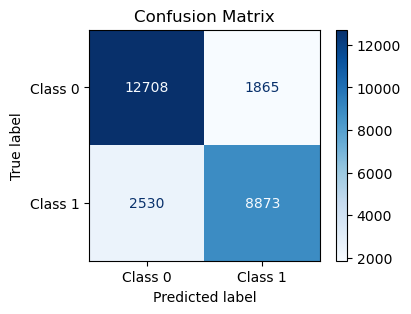

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier


dummy_model = DummyClassifier(strategy="most_frequent")
print("--- Dummy Baseline ---")
run_model(dummy_model, X_train, y_train, X_test)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

baseline_model = make_pipeline(StandardScaler(), LogisticRegression())
print("\n--- Logistic Regression Baseline ---")
baseline_model, baseline_preds = run_model(baseline_model, X_train, y_train, X_test)

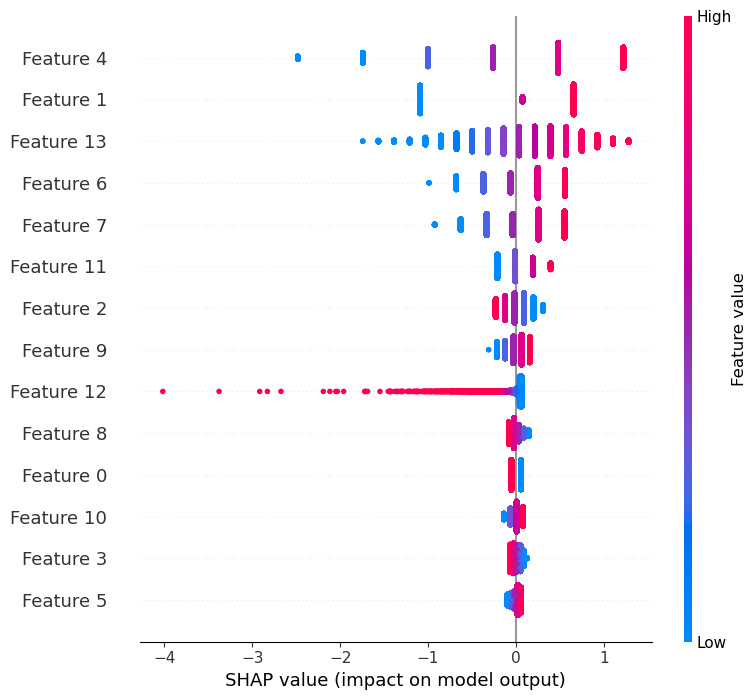

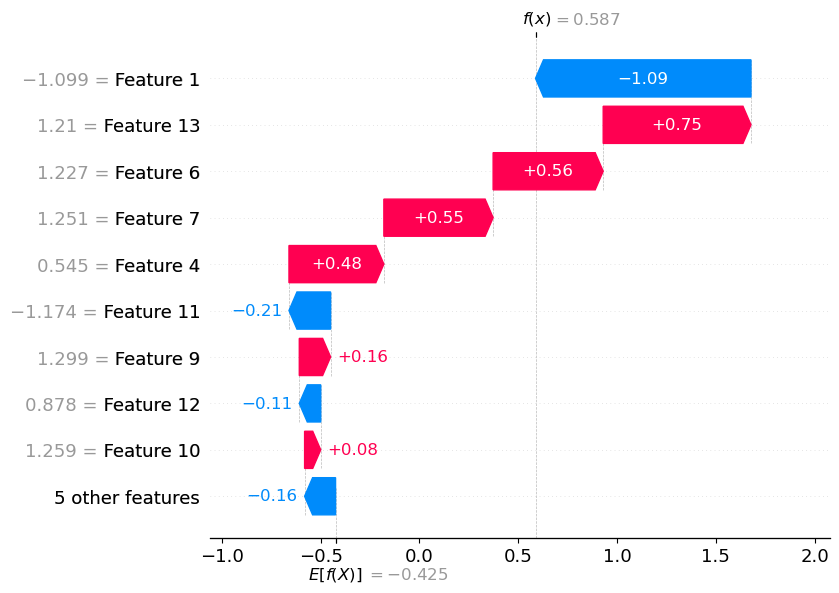

In [12]:
import shap

explainer = shap.LinearExplainer(logistic_model, X_train)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)
shap.plots.waterfall(explainer(X_test)[0])